# Data Sampling

We need target-input pairs where based on the input it would generate the proper answer
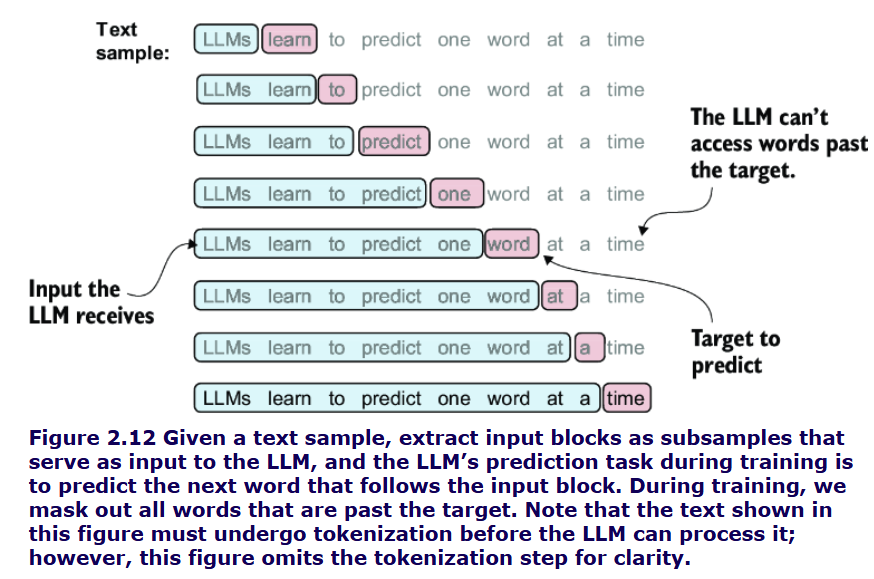

In [2]:
pip install tiktoken


Note: you may need to restart the kernel to use updated packages.


c:\Users\liamj\OneDrive\Documents\LLM\.venv\Scripts\python.exe: No module named pip


In [3]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [4]:
enc_sample = enc_text[50:]

context_size = 4
#sliding window with 4 tokens included in the inptu
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]
print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [5]:
#now that we have the inputs and the targets(the shiftedd by one spot) 
#we can do next word prediction 

for i in range(1, context_size+1):
    #matches the previous text before the word to what the word is 
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [6]:
for i in range(1, context_size+1):
    #matches the previous text before the word to what the word is 
    #decoded version 
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


We need an iterator that goes over the input dataset and return the inputs and targets. Specifically tensors for pytorch to process. 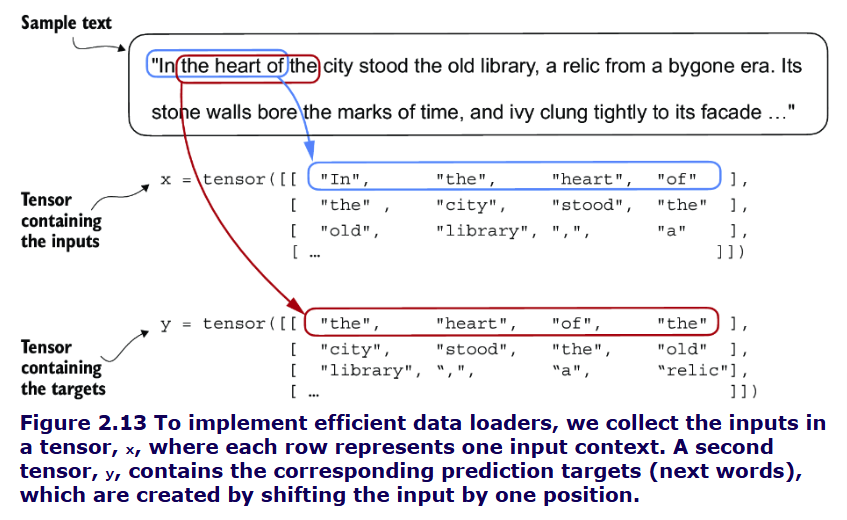

# Data loader


In [7]:
import torch 
from torch.utils.data import Dataset, DataLoader


#custom dataset for input-target pairs 
class GPTDatasetV1(Dataset):
    
    def __init__(self,txt,tokenizer,max_length, stride):
        self.input_ids = [] #hold all input ids
        self.target_ids = [] #hold all corresponding target target ids (word after the input)

        token_ids = tokenizer.encode(txt) #encoding the text into token ids 

        #sliding window to get input-target pairs
        for i in range(0,len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i+max_length] #input from i -> i + max length
            target_chunk = token_ids[i+1: i+max_length+1] #target shifted by 1 spot

            #append the input and target chunks as Tensors to be used in the dataloader
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


In [8]:

#function to create dataloader from dataset
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
    #intialize Byte Pair encoding tokenizer 
    tokenizer = tiktoken.get_encoding("gpt2")
    
    #create dataset(input-target paits) with txt 
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    #use dataloader to create batches of data (refer to appendix but high-level-> batches allow parallel processing and efficient training)
    dataloader = DataLoader(
        dataset, 
        batch_size = batch_size, #num of samples(input-target pairs) in each batch
        shuffle = shuffle, 
        drop_last = drop_last, # if smaller than batch size, drop the last batch
        num_workers = num_workers
    )
    return dataloader 

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)

data_iter = iter(dataloader) #iterable mode 
first_batch = next(data_iter) #get first batch of data (input-target pair) from the dataloader
print(first_batch)

second_batch = next(data_iter) #get second batch of data (input-target pair) from the dataloader
print(second_batch)
#you are able to see the overlap and the shift

# Test DataLoader with batch size of 8, max_length=4, stride=4
#with stride at 4 is bascially where the next batch starts so after 4 tokens, meaning no overlap since max length is also 4. 
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)
data_iter = iter(dataloader)
input,target = next(data_iter)

print("Input batch:", input)
print("Target batch:", target)
#no overlap could be a good thing to prevent overfitting but also less training data. 

    

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]
Input batch: tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Target batch: tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])
